#Data Dict :

1. data - tells whether the data is testing or training data
2. trip_creation_time – Timestamp of trip creation
3. route_schedule_uuid – Unique Id for a particular route schedule
4. route_type – Transportation type
5. FTL – Full Truck Load: FTL shipments get to the destination sooner, as the 6. truck is making no other pickups or drop-offs along the way
7. Carting: Handling system consisting of small vehicles (carts)
8. trip_uuid - Unique ID given to a particular trip (A trip may include different source and destination centers)
9. source_center - Source ID of trip origin
10. source_name - Source Name of trip origin
11. destination_cente – Destination ID
12. destination_name – Destination Name
13. od_start_time – Trip start time
14. od_end_time – Trip end time
15. start_scan_to_end_scan – Time taken to deliver from source to destination
16. is_cutoff – Unknown field
17. cutoff_factor – Unknown field
18. cutoff_timestamp – Unknown field
19. actual_distance_to_destination – Distance in Kms between source and destination warehouse
20. actual_time – Actual time taken to complete the delivery (Cumulative)
21. osrm_time – An open-source routing engine time calculator which computes the shortest path between points in a given map (Includes usual traffic, distance through major and minor roads) and gives the time (Cumulative)
22. osrm_distance – An open-source routing engine which computes the shortest path between points in a given map (Includes usual traffic, distance through major and minor roads) (Cumulative)
23. factor – Unknown field
24. segment_actual_time – This is a segment time. Time taken by the subset of the package delivery
25. segment_osrm_time – This is the OSRM segment time. Time taken by the subset of the package delivery
26. segment_osrm_distance – This is the OSRM distance. Distance covered by subset of the package delivery
27. segment_factor – Unknown field

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from scipy.stats import norm
from statsmodels.stats.weightstats import ztest
from scipy.stats import ttest_1samp, ttest_ind, ttest_ind_from_stats, f_oneway, kruskal, chi2_contingency
from sklearn.impute import SimpleImputer

In [ ]:
df = pd.read_csv('/content/delhivery_data.txt')

In [ ]:
df

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:57:20,45.258278,94.0,60.0,67.9280,1.566667,12.0,12.0,8.1858,1.000000
144863,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:31:18,54.092531,120.0,76.0,85.6829,1.578947,26.0,21.0,17.3725,1.238095
144864,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:11:18,66.163591,140.0,88.0,97.0933,1.590909,20.0,34.0,20.7053,0.588235
144865,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 20:53:19,73.680667,158.0,98.0,111.2709,1.612245,17.0,27.0,18.8885,0.629630


#Data Exploration

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [ ]:
#Changing data types of columns
df["trip_creation_time"] = pd.to_datetime(df["trip_creation_time"])
df["od_start_time"] = pd.to_datetime(df["od_start_time"])
df["od_end_time"] = pd.to_datetime(df["od_end_time"])
df["cutoff_timestamp"] = pd.to_datetime(df["cutoff_timestamp"],errors = 'coerce')


In [ ]:
#Chceking for null values in the columns
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


In [ ]:
# Data shape
df.shape

(144867, 24)

In [ ]:
#difference between trip start time and trip end time

df['od_delivery_time'] = df['od_end_time'] - df['od_start_time']
df['od_delivery_time'].head(10)

,od_delivery_time
0,0 days 01:26:12.818197
1,0 days 01:26:12.818197
2,0 days 01:26:12.818197
3,0 days 01:26:12.818197
4,0 days 01:26:12.818197
5,0 days 01:49:10.390967
6,0 days 01:49:10.390967
7,0 days 01:49:10.390967
8,0 days 01:49:10.390967
9,0 days 01:49:10.390967


In [ ]:
#since the differnce in delivery start time and delivery end time is in mintues we will convert the column for mintues.

df['delivery_minutes'] = pd.to_timedelta(df['od_delivery_time']).dt.total_seconds() / 60

df["delivery_minutes"].head(10)

,delivery_minutes
0,86.213637
1,86.213637
2,86.213637
3,86.213637
4,86.213637
5,109.173183
6,109.173183
7,109.173183
8,109.173183
9,109.173183


In [ ]:
group1 = df.groupby(['trip_uuid','source_center','destination_center'],sort =False).agg(od_centre_time=('delivery_minutes','mean'),
                                                                                    scan_centre_time =('start_scan_to_end_scan','mean'),
                                                                                    actual_centre_time = ('actual_time','last'),
                                                                                    osrm_centre_time = ('osrm_time','last'),
                                                                                    segment_actual_time = ('segment_actual_time','sum'),
                                                                                    segment_osrm_time = ('segment_osrm_time','sum'),
                                                                                    segment_osrm_distance = ('segment_osrm_distance','sum'),
                                                                                    osrm_centre_distance = ('osrm_distance','last'),
                                                                                    actual_centre_distance = ('actual_distance_to_destination','last'),
                                                                                    segment_osrm_centre_distance = ('segment_osrm_distance','sum')

                                                                                    )


In [ ]:
group2 = group1.groupby('trip_uuid').agg(od_total_time = ('od_centre_time','sum'),
                                         scan_total_time = ('scan_centre_time','sum'),
                                         actual_total_time = ('actual_centre_time','sum'),
                                         osrm_total_time = ('osrm_centre_time','sum'),
                                         segment_actual_total_time = ('segment_actual_time','sum'),
                                         segment_osrm_total_time = ('segment_osrm_time','sum'),

                                         osrm_total_distance=('osrm_centre_distance','sum'),
                                         actual_total_distance=('actual_centre_distance','sum'),
                                        segment_osrm_total_distance=('segment_osrm_centre_distance','sum'))
group2.reset_index(inplace=True)
group2


,trip_uuid,od_total_time,scan_total_time,actual_total_time,osrm_total_time,segment_actual_total_time,segment_osrm_total_time,osrm_total_distance,actual_total_distance,segment_osrm_total_distance
0,trip-153671041653548748,2260.109800,2259.0,1562.0,717.0,1548.0,1008.0,991.3523,824.732854,1320.4733
1,trip-153671042288605164,181.611874,180.0,143.0,68.0,141.0,65.0,85.1110,73.186911,84.1894
2,trip-153671043369099517,3934.362520,3933.0,3347.0,1740.0,3308.0,1941.0,2354.0665,1927.404273,2545.2678
3,trip-153671046011330457,100.494935,100.0,59.0,15.0,59.0,16.0,19.6800,17.175274,19.8766
4,trip-153671052974046625,718.349042,717.0,341.0,117.0,340.0,115.0,146.7918,127.448500,146.7919
...,...,...,...,...,...,...,...,...,...,...
14812,trip-153861095625827784,258.028928,257.0,83.0,62.0,82.0,62.0,73.4630,57.762332,64.8551
14813,trip-153861104386292051,60.590521,60.0,21.0,12.0,21.0,11.0,16.0882,15.513784,16.0883
14814,trip-153861106442901555,422.119867,421.0,282.0,48.0,281.0,88.0,58.9037,38.684839,104.8866
14815,trip-153861115439069069,348.512862,347.0,264.0,179.0,258.0,221.0,171.1103,134.723836,223.5324


In [ ]:
group2.describe()

,od_total_time,scan_total_time,actual_total_time,osrm_total_time,segment_actual_total_time,segment_osrm_total_time,osrm_total_distance,actual_total_distance,segment_osrm_total_distance
count,14817.000000,14817.000000,14817.000000,14817.000000,14817.000000,14817.000000,14817.000000,14817.000000,14817.000000
mean,531.682927,530.795235,357.143754,161.384018,353.892286,180.949787,204.344689,164.477838,223.201161
std,658.839073,658.676701,561.396157,271.360995,556.247965,314.542047,370.395573,305.388147,416.628374
min,23.461468,23.000000,9.000000,6.000000,9.000000,6.000000,9.072900,9.002461,9.072900
25%,149.930591,149.000000,67.000000,29.000000,66.000000,31.000000,30.819200,22.837239,32.654500
50%,280.765626,280.000000,149.000000,60.000000,147.000000,65.000000,65.618800,48.474072,70.154400
75%,638.199071,637.000000,370.000000,168.000000,367.000000,185.000000,208.475000,164.583208,218.802400
max,7898.551955,7898.000000,6265.000000,2032.000000,6230.000000,2564.000000,2840.081000,2186.531787,3523.632400


There are 14817 trips in the dataset

Text(0.5, 1.0, 'Segment wise OSRM total distance taken across various trips')

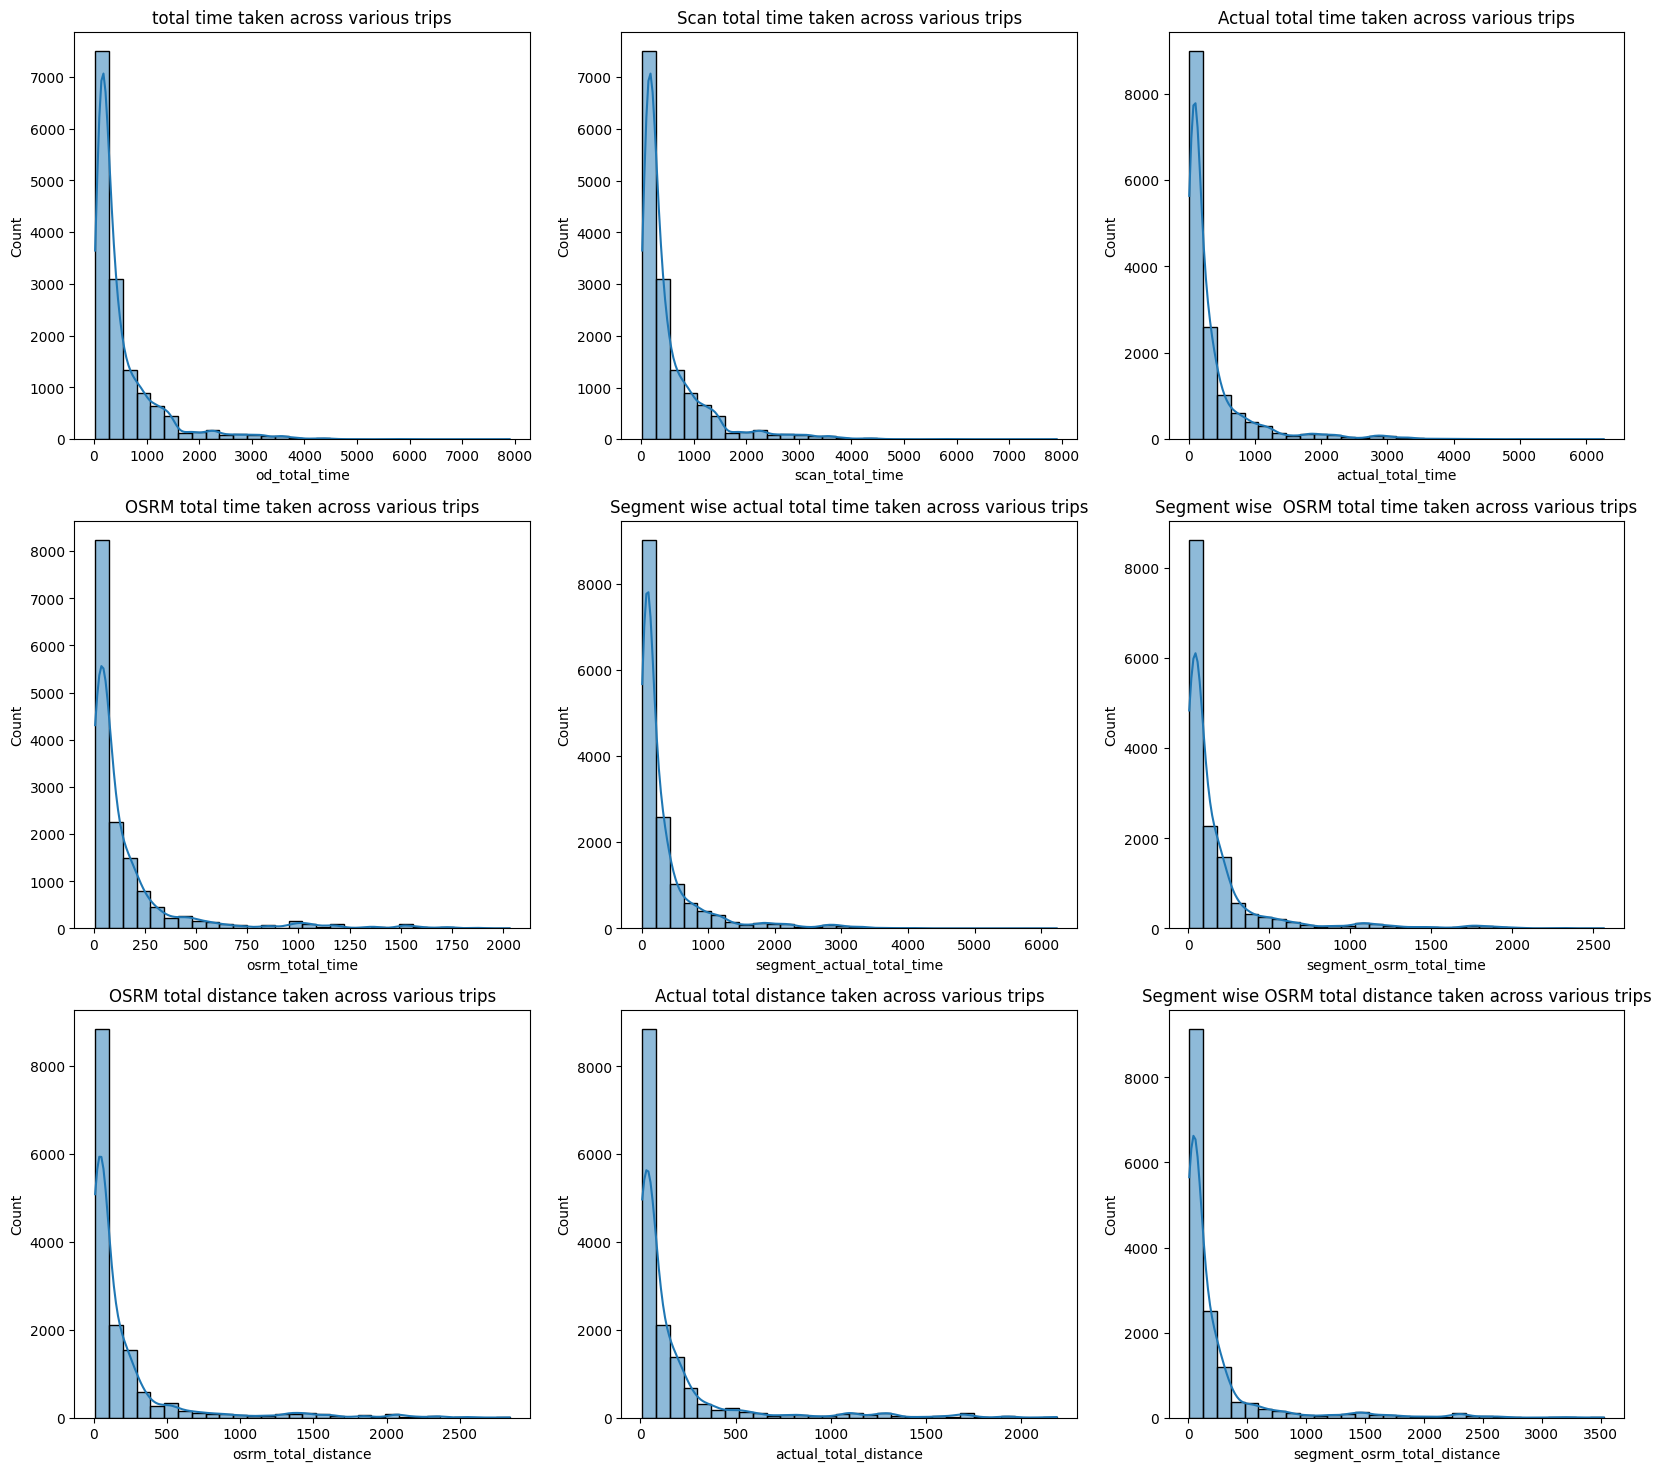

In [ ]:
#histplot to visualize the distribution of various distances and time taken by every trip id

plt.figure(figsize = (20,18))

plt.subplot(3,3,1)

sns.histplot(group2['od_total_time'],bins=30,kde=True)
plt.title('total time taken across various trips')

plt.subplot(3,3,2)
sns.histplot(group2['scan_total_time'],bins=30,kde=True)
plt.title('Scan total time taken across various trips')

plt.subplot(3,3,3)
sns.histplot(group2['actual_total_time'],bins=30,kde=True)
plt.title('Actual total time taken across various trips')

plt.subplot(3,3,4)
sns.histplot(group2['osrm_total_time'],bins=30,kde=True)
plt.title('OSRM total time taken across various trips')

plt.subplot(3,3,5)
sns.histplot(group2['segment_actual_total_time'],bins=30,kde=True)
plt.title('Segment wise actual total time taken across various trips')

plt.subplot(3,3,6)
sns.histplot(group2['segment_osrm_total_time'],bins=30,kde=True)
plt.title('Segment wise  OSRM total time taken across various trips')


plt.subplot(3,3,7)
sns.histplot(group2['osrm_total_distance'],bins=30,kde=True)
plt.title('OSRM total distance taken across various trips')


plt.subplot(3,3,8)
sns.histplot(group2['actual_total_distance'],bins=30,kde=True)
plt.title('Actual total distance taken across various trips')

plt.subplot(3,3,9)
sns.histplot(group2['segment_osrm_total_distance'],bins=30,kde=True)
plt.title('Segment wise OSRM total distance taken across various trips')





Text(0.5, 1.0, 'Segment wise OSRM total distance taken')

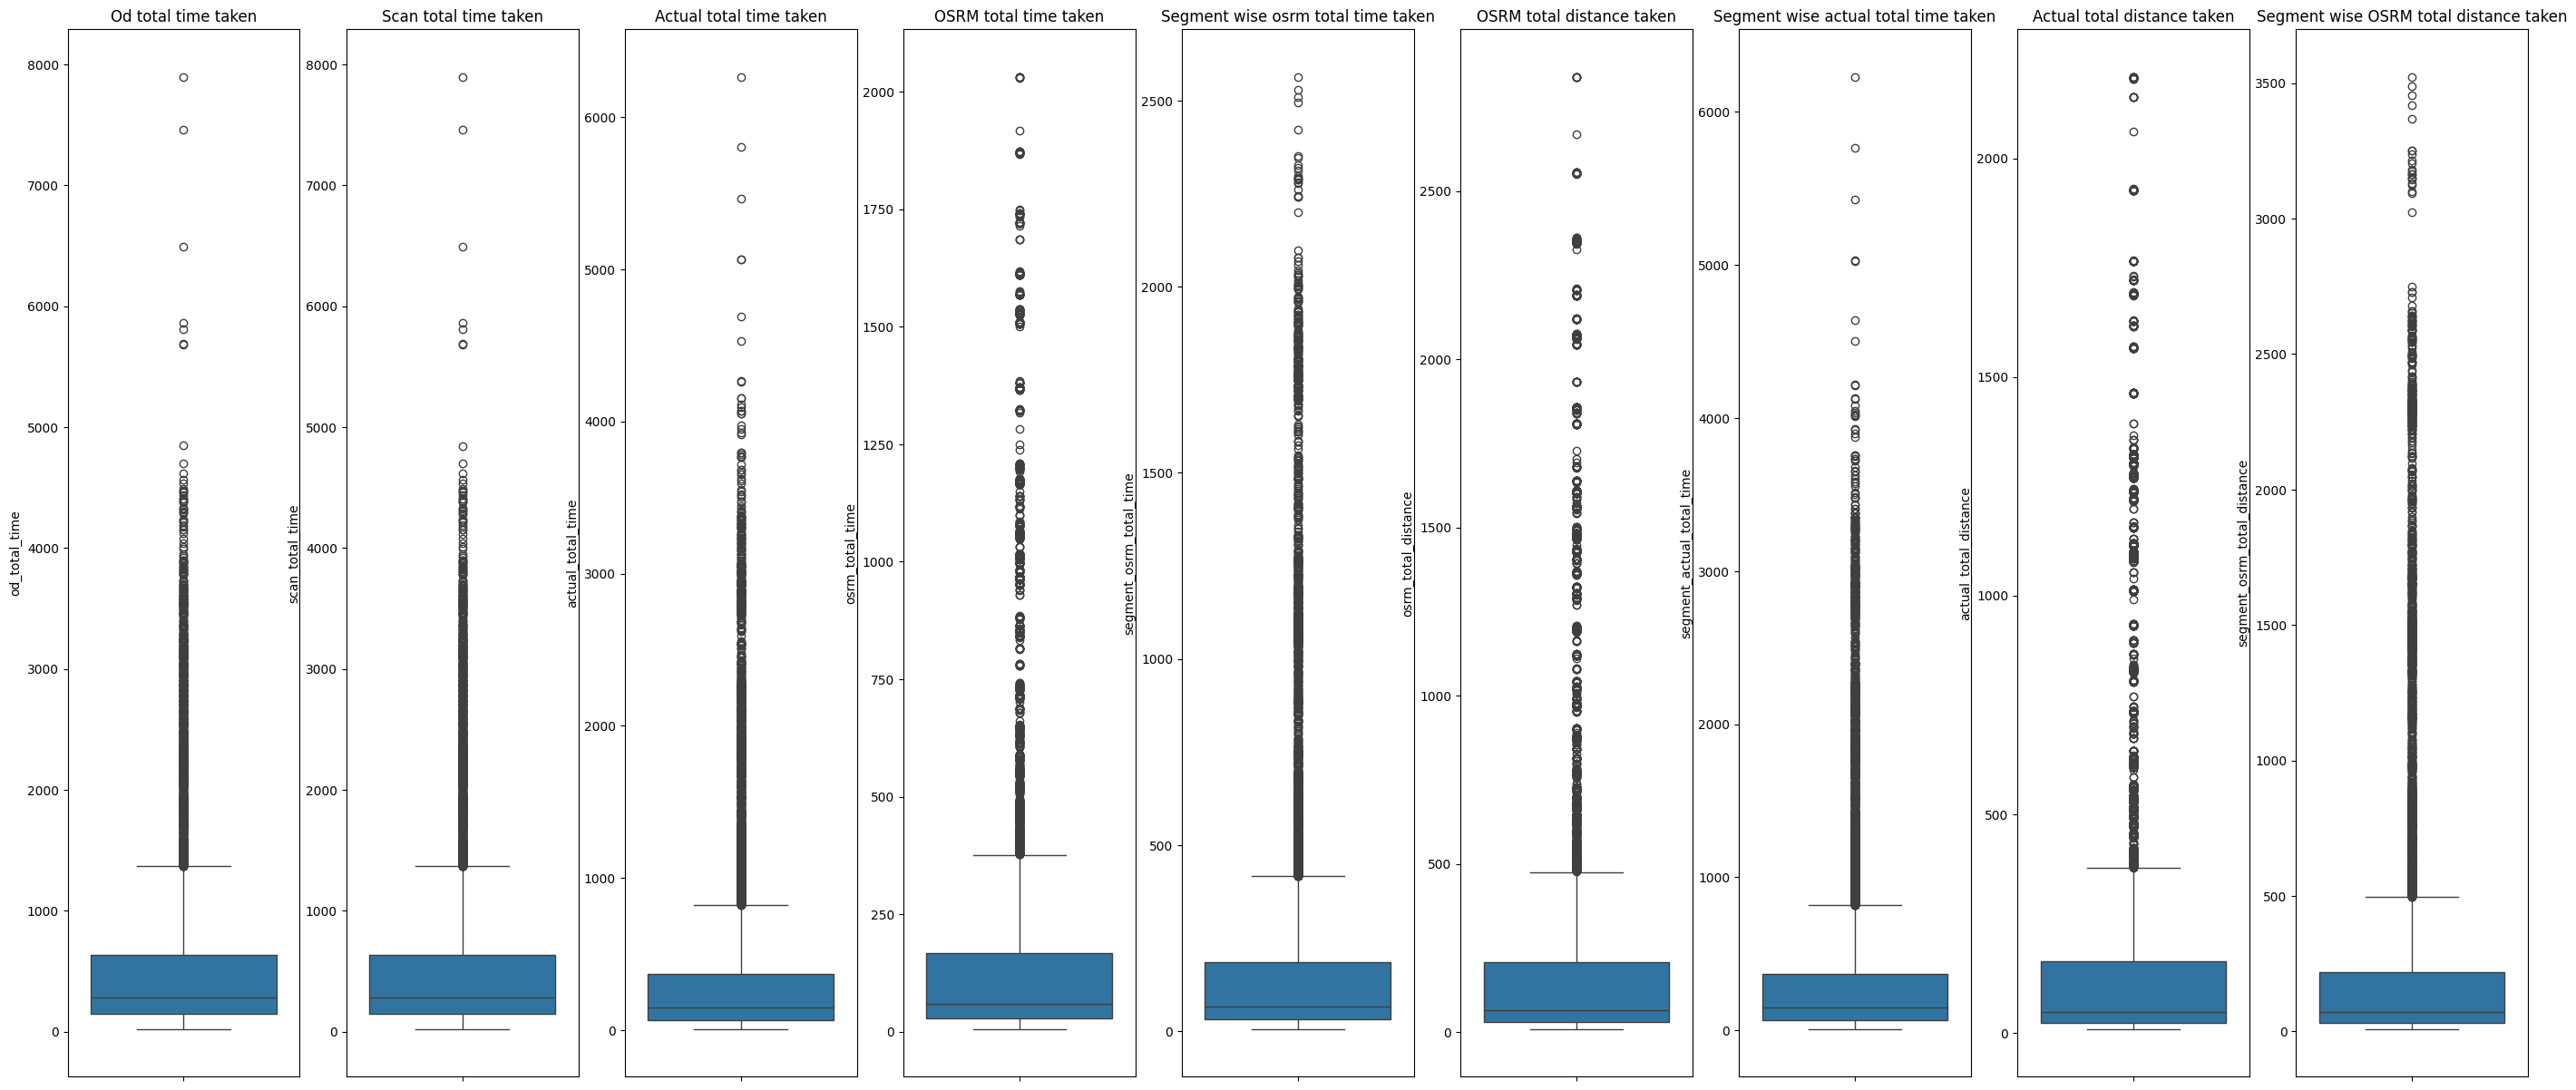

In [ ]:
# Box plot to visualize the total distances covered and total time taken

plt.figure(figsize = (35,15))

plt.subplot(1,9,1)
sns.boxplot(group2['od_total_time'])
plt.title('Od total time taken')

plt.subplot(1,9,2)
sns.boxplot(group2['scan_total_time'])
plt.title("Scan total time taken")

plt.subplot(1,9,3)
sns.boxplot(group2['actual_total_time'])
plt.title("Actual total time taken")

plt.subplot(1,9,4)
sns.boxplot(group2['osrm_total_time'])
plt.title("OSRM total time taken")

plt.subplot(1,9,5)
sns.boxplot(group2['segment_osrm_total_time'])
plt.title("Segment wise osrm total time taken")

plt.subplot(1,9,6)
sns.boxplot(group2['osrm_total_distance'])
plt.title("OSRM total distance taken")

plt.subplot(1,9,7)
sns.boxplot(group2['segment_actual_total_time'])
plt.title("Segment wise actual total time taken")



plt.subplot(1,9,8)
sns.boxplot(group2["actual_total_distance"])
plt.title("Actual total distance taken")

plt.subplot(1,9,9)
sns.boxplot(group2["segment_osrm_total_distance"])
plt.title("Segment wise OSRM total distance taken")

#Handling Outlier using IQR Method

In [ ]:
#Time
IQR_odtt = np.quantile(group2['od_total_time'],0.75) - np.quantile(group2['od_total_time'],0.25)
IQR_stt = np.quantile(group2['scan_total_time'],0.75) - np.quantile(group2['scan_total_time'],0.25)
IQR_att = np.quantile(group2['actual_total_time'],0.75) - np.quantile(group2['actual_total_time'],0.25)
IQR_ostt = np.quantile(group2['osrm_total_time'],0.75) - np.quantile(group2['osrm_total_time'],0.25)
IQR_sat =  np.quantile(group2['segment_actual_total_time'],0.75) - np.quantile(group2['segment_actual_total_time'],0.25)
IQR_sost = np.quantile(group2['segment_osrm_total_time'],0.75) - np.quantile(group2['segment_osrm_total_time'],0.25)
#Distances
IQR_ostd = np.quantile(group2['osrm_total_distance'],0.75) - np.quantile(group2['osrm_total_distance'],0.25)
IQR_atd = np.quantile(group2['actual_total_distance'],0.75) - np.quantile(group2['actual_total_distance'],0.25)
IQR_sotd = np.quantile(group2['segment_osrm_total_distance'],0.75) - np.quantile(group2['segment_osrm_total_distance'],0.25)

print("IQR_odtt:",IQR_odtt)
print("IQR_stt:",IQR_stt)
print("IQR_att:",IQR_att)
print("IQR_ostt:",IQR_ostt)
print("IQR_sat:",IQR_sat)
print("IQR_sost:",IQR_sost)
print("IQR_ostd:",IQR_ostd)
print("IQR_atd:",IQR_atd)
print("IQR_sotd:",IQR_sotd)



IQR_odtt: 488.2684801999999
IQR_stt: 488.0
IQR_att: 303.0
IQR_ostt: 139.0
IQR_sat: 301.0
IQR_sost: 154.0
IQR_ostd: 177.6558
IQR_atd: 141.74596857981817
IQR_sotd: 186.1479


In [ ]:
group2_without_distance_outlier = group2.loc[(group2['actual_total_distance']>=(np.quantile(group2['actual_total_distance'],0.25)-1.5*IQR_atd)) & (group2['actual_total_distance']<=(np.quantile(group2['actual_total_distance'],0.75)+1.5*IQR_atd))]['actual_total_distance']

len(group2) - len(group2_without_distance_outlier)  #number of outlier of actual total distance covered



1449

In [ ]:
group2_without_tt_outliers = group2.loc[(group2['actual_total_time']>=(np.quantile(group2['actual_total_time'],0.25)-1.5*IQR_att)) &
      (group2['actual_total_time']<=(np.quantile(group2['actual_total_time'],0.75)+1.5*IQR_att))]['actual_total_time']
len(group2)-len(group2_without_tt_outliers)       # number of outliers of actual total time taken

1643

# The various distances and time taken for every trip are important, therefore we cannot remove the outliers here.

In [ ]:
group2.head()

,trip_uuid,od_total_time,scan_total_time,actual_total_time,osrm_total_time,segment_actual_total_time,segment_osrm_total_time,osrm_total_distance,actual_total_distance,segment_osrm_total_distance
0,trip-153671041653548748,2260.109800,2259.0,1562.0,717.0,1548.0,1008.0,991.3523,824.732854,1320.4733
1,trip-153671042288605164,181.611874,180.0,143.0,68.0,141.0,65.0,85.1110,73.186911,84.1894
2,trip-153671043369099517,3934.362520,3933.0,3347.0,1740.0,3308.0,1941.0,2354.0665,1927.404273,2545.2678
3,trip-153671046011330457,100.494935,100.0,59.0,15.0,59.0,16.0,19.6800,17.175274,19.8766
4,trip-153671052974046625,718.349042,717.0,341.0,117.0,340.0,115.0,146.7918,127.448500,146.7919


In [ ]:
# Standard Normalization
cols_std = group2[[col for col in group2.columns if col != 'trip_uuid']]

group2_std_scaled = StandardScaler().fit_transform(cols_std)
gp2_std_scaled = pd.DataFrame(group2_std_scaled,columns = cols_std.columns)
gp2_std_scaled.head()




,od_total_time,scan_total_time,actual_total_time,osrm_total_time,segment_actual_total_time,segment_osrm_total_time,osrm_total_distance,actual_total_distance,segment_osrm_total_distance
0,2.623532,2.623841,2.146251,2.047585,2.146791,2.629468,2.124848,2.162092,2.633784
1,-0.531363,-0.532594,-0.381461,-0.344144,-0.382742,-0.368643,-0.321920,-0.298944,-0.333670
2,5.164834,5.165386,5.325931,5.817598,5.310954,5.595785,5.804050,5.772935,5.573660
3,-0.654488,-0.654053,-0.531093,-0.539462,-0.530163,-0.524430,-0.498578,-0.482362,-0.488040
4,0.283335,0.282705,-0.028757,-0.163566,-0.024976,-0.209676,-0.155387,-0.121257,-0.183405


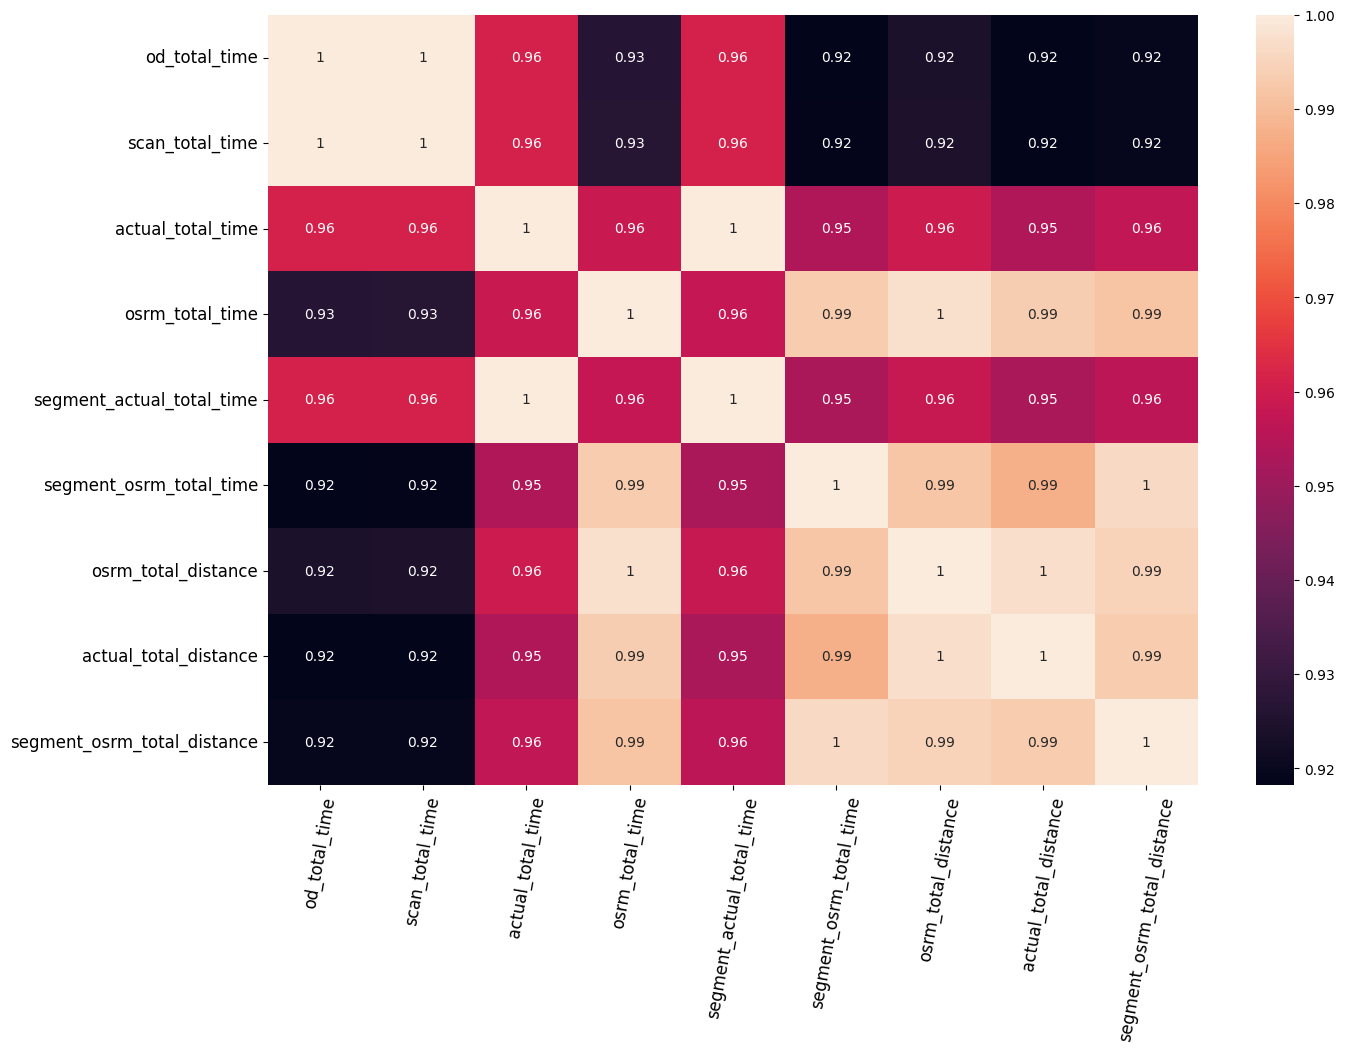

In [ ]:
# Heatmap to visualize the correlation between numerical columns for each trip id

plt.figure(figsize = (15,10))

sns.heatmap(gp2_std_scaled.corr(),annot = True)

plt.xticks(rotation=80,fontsize=12)

plt.yticks(fontsize=12)

plt.show()

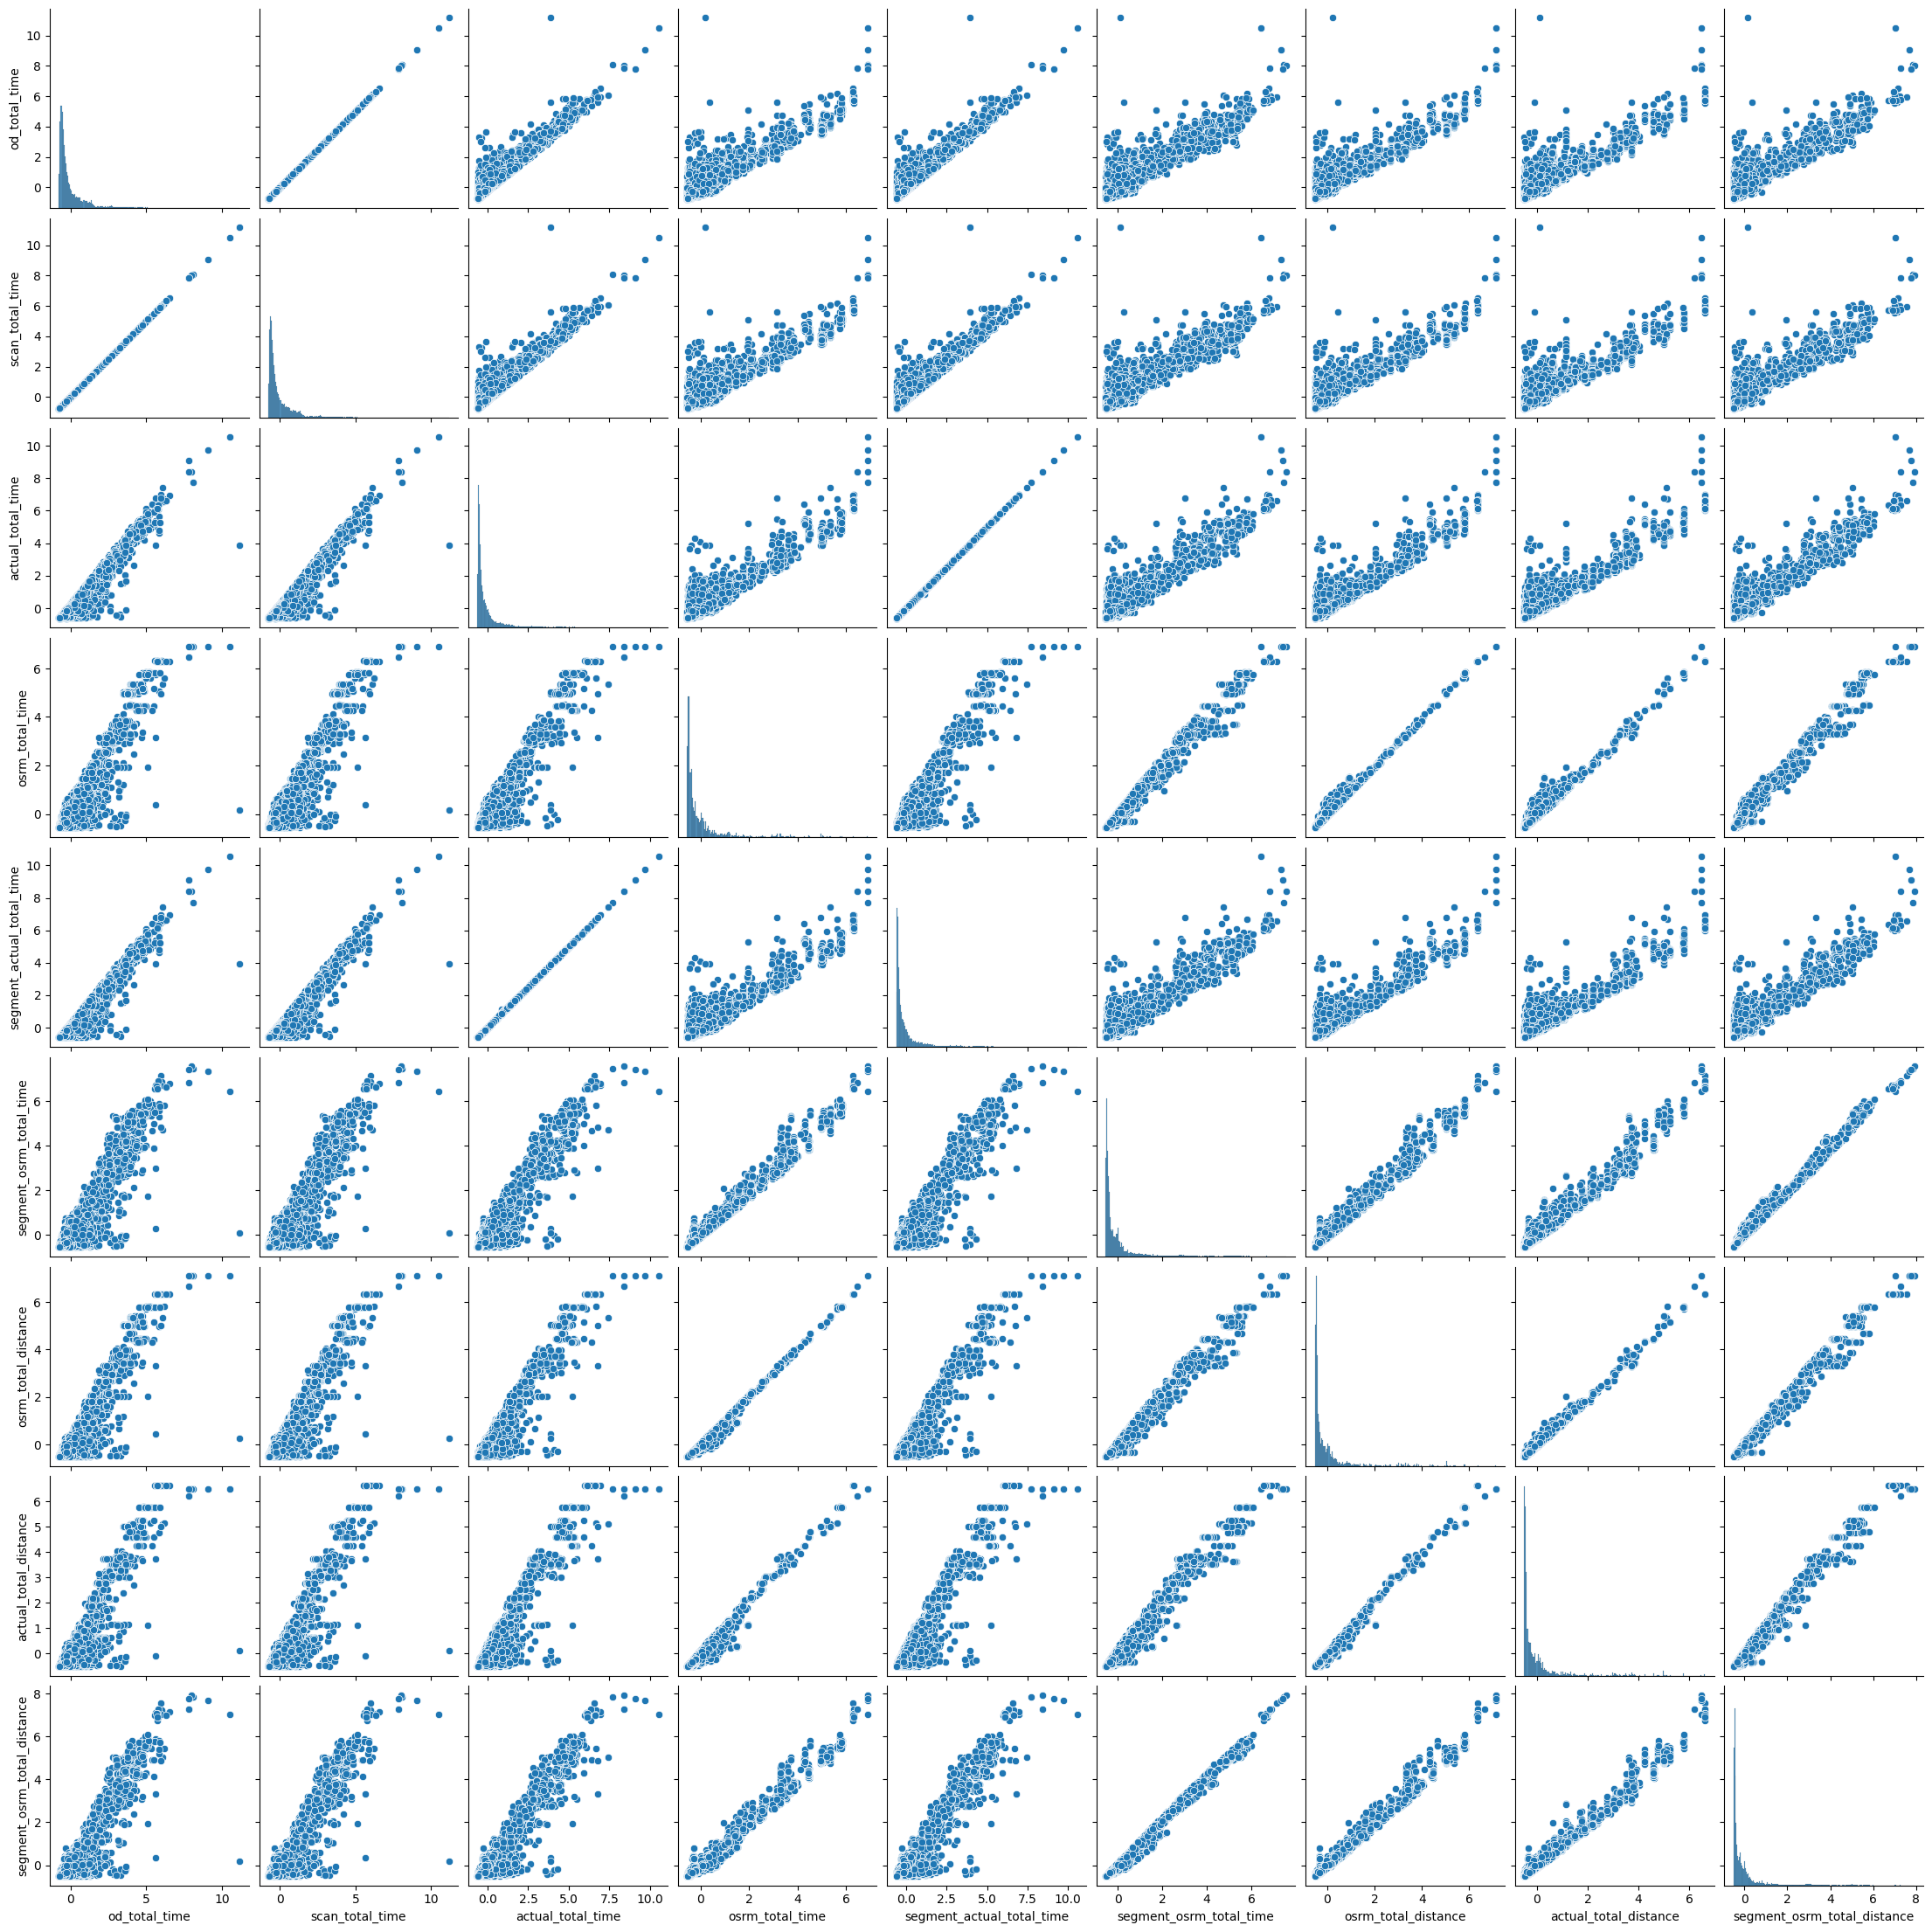

In [ ]:
#pairplot to visulize the relation between every numerical column for each trip id

sns.pairplot(gp2_std_scaled)

In [ ]:
# MinMax Normalization

mm_scaled = MinMaxScaler().fit_transform(cols_std)
gp2_mm_scaled = pd.DataFrame(mm_scaled,columns = cols_std.columns)
gp2_mm_scaled.head()


,od_total_time,scan_total_time,actual_total_time,osrm_total_time,segment_actual_total_time,segment_osrm_total_time,osrm_total_distance,actual_total_distance,segment_osrm_total_distance
0,0.284016,0.283937,0.248242,0.350938,0.247388,0.391712,0.346972,0.374613,0.373134
1,0.020082,0.019937,0.021419,0.030602,0.021218,0.023065,0.026859,0.029476,0.021373
2,0.496617,0.496508,0.533568,0.855874,0.530301,0.756450,0.828325,0.880999,0.721625
3,0.009782,0.009778,0.007992,0.004442,0.008037,0.003909,0.003747,0.003753,0.003074
4,0.088239,0.088127,0.053069,0.054788,0.053207,0.042611,0.048647,0.054395,0.039185


In [ ]:
feature_1 = df.groupby(['trip_uuid','source_name','destination_name'],sort=False).agg(total_distance_per_centre = ('actual_distance_to_destination','last'),
                                                                          total_time_per_centre = ('actual_time','last'))
feature_1.reset_index(inplace=True)
feature_1

,trip_uuid,source_name,destination_name,total_distance_per_centre,total_time_per_centre
0,trip-153741093647649320,Anand_VUNagar_DC (Gujarat),Khambhat_MotvdDPP_D (Gujarat),39.386040,68.0
1,trip-153741093647649320,Khambhat_MotvdDPP_D (Gujarat),Anand_Vaghasi_IP (Gujarat),43.595802,102.0
2,trip-153768492602129387,Bhiwandi_Mankoli_HB (Maharashtra),Pune_Tathawde_H (Maharashtra),100.708423,183.0
3,trip-153693976643699843,LowerParel_CP (Maharashtra),Mumbai_Chndivli_PC (Maharashtra),16.431273,60.0
4,trip-153687145942424248,Bangalore_Nelmngla_H (Karnataka),Bengaluru_Bomsndra_HB (Karnataka),39.806036,67.0
...,...,...,...,...,...
26217,trip-153799142965708367,Jaora_RtlamNka_D (Madhya Pradesh),Ahmedabad_East_H_1 (Gujarat),265.367032,484.0
26218,trip-153695073416451616,Mumbai_Jogeshwri_L (Maharashtra),Bhiwandi_Mankoli_HB (Maharashtra),23.034042,344.0
26219,trip-153761584139918815,Bhiwandi_Mankoli_HB (Maharashtra),Pune_Tathawde_H (Maharashtra),100.562078,289.0
26220,trip-153718412883843340,MAA_Poonamallee_HB (Tamil Nadu),Chennai_Hub (Tamil Nadu),31.698687,84.0


In [ ]:
#Feature creation

feature_1['Source_state'] = df['source_name'].str.extract(r'\((.*?)\)')
feature_1['destination_state'] = df['destination_name'].str.extract(r'\((.*?)\)')

In [ ]:
# Grouping by trip id, source state, and destination state to get the total distance and total time to deliver for each trip id across two states
states_gp = feature_1.groupby(['trip_uuid','Source_state','destination_state'],sort=False).agg(total_distance_covered=('total_distance_per_centre','sum'), # changed 'total_distance_per_center' to 'total_distance_per_centre'
                                                                total_time_taken=('total_time_per_centre','sum')) # changed 'total_time_per_center' to 'total_time_per_centre'
states_gp.reset_index(inplace=True)
states_gp

,trip_uuid,Source_state,destination_state,total_distance_covered,total_time_taken
0,trip-153741093647649320,Gujarat,Gujarat,82.981842,170.0
1,trip-153768492602129387,Gujarat,Gujarat,100.708423,183.0
2,trip-153693976643699843,Gujarat,Gujarat,16.431273,60.0
3,trip-153687145942424248,Gujarat,Gujarat,371.458435,805.0
4,trip-153825970514894360,Gujarat,Gujarat,95.488499,152.0
...,...,...,...,...,...
15958,trip-153799142965708367,Telangana,Maharashtra,265.367032,484.0
15959,trip-153695073416451616,Telangana,Maharashtra,23.034042,344.0
15960,trip-153761584139918815,Telangana,Maharashtra,100.562078,289.0
15961,trip-153718412883843340,Telangana,Maharashtra,31.698687,84.0


In [ ]:
#States from where most of the orders are taken in descending order

states_gp['Source_state'].value_counts(normalize=True)*100

,proportion
Source_state,
Haryana,19.683017
Maharashtra,13.994863
Karnataka,12.767024
Tamil Nadu,5.951262
Telangana,4.811126
Uttar Pradesh,4.641985
Andhra Pradesh,4.548017
Gujarat,4.190942
Rajasthan,3.833866


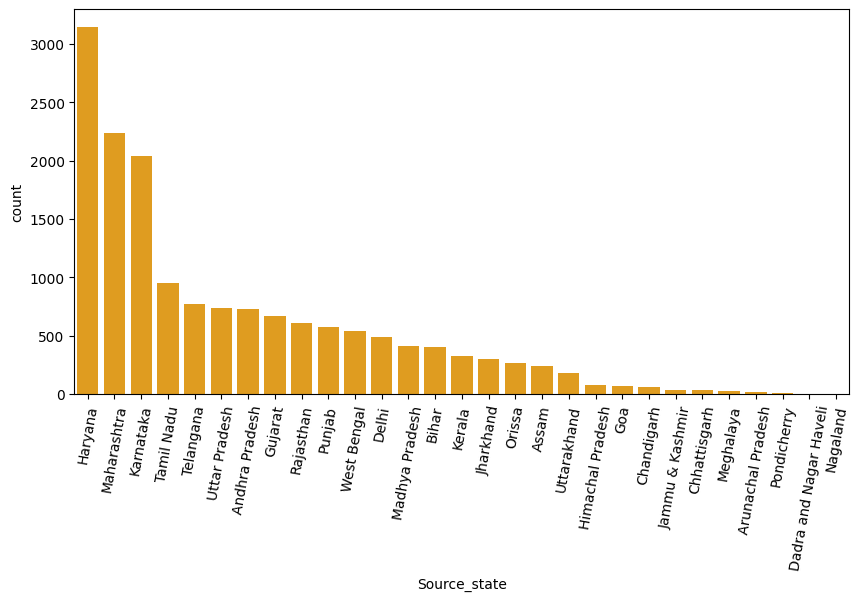

In [ ]:
#Countplot to visualize the state from where  the most orders  were sourced in desc

plt.figure(figsize=(10,5))
sns.countplot(x=states_gp['Source_state'],order=states_gp['Source_state'].value_counts().index,color ='orange')
plt.xticks(rotation=80,fontsize=10)
plt.show()

In [ ]:
#Busiest corridor
states_gp[['Source_state','destination_state']].value_counts(normalize=True).head(10)*100

,,proportion
Source_state,destination_state,
Maharashtra,Maharashtra,8.551024
Karnataka,Karnataka,8.394412
Tamil Nadu,Tamil Nadu,5.180730
Uttar Pradesh,Uttar Pradesh,3.414145
Haryana,Haryana,3.376558
Rajasthan,Rajasthan,3.351500
Haryana,Karnataka,3.345236
Gujarat,Gujarat,2.956838
Andhra Pradesh,Andhra Pradesh,2.925515


In [ ]:
#Non-busy Corridors

states_gp[['Source_state','destination_state']].value_counts().tail(10)

,,count
Source_state,destination_state,
Chandigarh,Chandigarh,6
Arunachal Pradesh,Assam,5
Delhi,Punjab,5
Dadra and Nagar Haveli,Gujarat,4
Nagaland,Assam,3
Rajasthan,Madhya Pradesh,3
Uttar Pradesh,Rajasthan,2
Assam,Arunachal Pradesh,2
Himachal Pradesh,Haryana,1


In [ ]:
# Grouping by source and destination state to get the mean distance and time to deliver between two states

state_gp1 = states_gp.groupby(['Source_state','destination_state'],sort=False).agg(mean_distance_covered=('total_distance_covered','mean'),
                                                                                  mean_time_taken=('total_time_taken','mean'))

state_gp1.reset_index(inplace=True)
state_gp1

,Source_state,destination_state,mean_distance_covered,mean_time_taken
0,Gujarat,Gujarat,156.636680,332.131356
1,Maharashtra,Maharashtra,141.899961,306.468864
2,Karnataka,Karnataka,140.539520,310.987313
3,Karnataka,Kerala,138.123392,302.096154
4,Punjab,Punjab,154.722459,329.904762
...,...,...,...,...
129,Delhi,Assam,147.097081,288.893617
130,Karnataka,Rajasthan,253.536742,543.588235
131,Rajasthan,Delhi,59.139214,109.285714
132,Assam,Arunachal Pradesh,88.389091,135.000000


In [ ]:
state_gp1.sort_values(by=['mean_time_taken','mean_distance_covered']).head(10)

,Source_state,destination_state,mean_distance_covered,mean_time_taken
126,Himachal Pradesh,Haryana,21.981517,37.000000
67,Goa,Goa,39.217666,87.777778
131,Rajasthan,Delhi,59.139214,109.285714
40,Punjab,Jammu & Kashmir,46.662466,125.615385
54,Haryana,Himachal Pradesh,63.561696,128.200000
110,Assam,Meghalaya,67.933598,130.333333
132,Assam,Arunachal Pradesh,88.389091,135.000000
90,Andhra Pradesh,Tamil Nadu,66.736343,136.625000
94,Gujarat,Dadra and Nagar Haveli,70.205460,136.928571
75,Pondicherry,Tamil Nadu,50.560458,150.153846


In [ ]:
df['route_type'].value_counts()

,count
route_type,
FTL,99660
Carting,45207


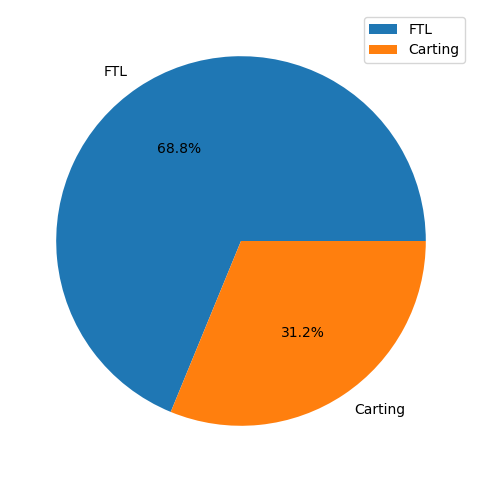

In [ ]:
#pieplot to visualize the proportion of various route types

plt.figure(figsize=(6,6))
plt.pie(df['route_type'].value_counts(),
        labels=df['route_type'].value_counts().index,
        autopct='%1.1f%%')
plt.legend(loc='upper right')
plt.show()

In [ ]:
#Performing one hot encoding on route type

df1=pd.get_dummies(df,columns = ['route_type'])
df1

,data,trip_creation_time,route_schedule_uuid,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,...,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,od_delivery_time,delivery_minutes,route_type_Carting,route_type_FTL
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,...,11.9653,1.272727,14.0,11.0,11.9653,1.272727,0 days 01:26:12.818197,86.213637,True,False
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,...,21.7243,1.200000,10.0,9.0,9.7590,1.111111,0 days 01:26:12.818197,86.213637,True,False
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,...,32.5395,1.428571,16.0,7.0,10.8152,2.285714,0 days 01:26:12.818197,86.213637,True,False
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,...,45.5620,1.550000,21.0,12.0,13.0224,1.750000,0 days 01:26:12.818197,86.213637,True,False
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,...,54.2181,1.545455,6.0,5.0,3.9153,1.200000,0 days 01:26:12.818197,86.213637,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,...,67.9280,1.566667,12.0,12.0,8.1858,1.000000,0 days 07:07:41.181838,427.686364,True,False
144863,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,...,85.6829,1.578947,26.0,21.0,17.3725,1.238095,0 days 07:07:41.181838,427.686364,True,False
144864,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,...,97.0933,1.590909,20.0,34.0,20.7053,0.588235,0 days 07:07:41.181838,427.686364,True,False
144865,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,2018-09-20 23:32:09.618069,...,111.2709,1.612245,17.0,27.0,18.8885,0.629630,0 days 07:07:41.181838,427.686364,True,False


In [ ]:
df2 = df1.groupby(['trip_uuid','source_center','destination_center'],sort=False).agg(actual_centre_distance = ('actual_distance_to_destination','last'),
                                                                                    actual_centre_time = ('actual_time','last'),
                                                                                    route_carting = ('route_type_Carting','max'),
                                                                                    route_ftl = ('route_type_FTL','max')
                                                                                     )
df2

actual_centre_distance  \
trip_uuid               source_center destination_center                           
trip-153741093647649320 IND388121AAA  IND388620AAB                     39.386040   
                        IND388620AAB  IND388320AAA                     43.595802   
trip-153768492602129387 IND421302AAG  IND411033AAA                    100.708423   
trip-153693976643699843 IND400011AAA  IND400072AAD                     16.431273   
trip-153687145942424248 IND562132AAA  IND560099AAB                     39.806036   
...                                                                          ...   
trip-153799142965708367 IND457226AAA  IND382430AAB                    265.367032   
trip-153695073416451616 IND400102AAB  IND421302AAG                     23.034042   
trip-153761584139918815 IND421302AAG  IND411033AAA                    100.562078   
trip-153718412883843340 IND600056AAB  IND600032AAB                     31.698687   
trip-153746066843555182 IND131028AAB  IND000000ACB                     70.039010   

                                                          actual_centre_time  \
trip_uuid               source_center destination_center                       
trip-153741093647649320 IND388121AAA  IND388620AAB                      68.0   
                        IND388620AAB  IND388320AAA                     102.0   
trip-153768492602129387 IND421302AAG  IND411033AAA                     183.0   
trip-153693976643699843 IND400011AAA  IND400072AAD                      60.0   
trip-153687145942424248 IND562132AAA  IND560099AAB                      67.0   
...                                                                      ...   
trip-153799142965708367 IND457226AAA  IND382430AAB                     484.0   
trip-153695073416451616 IND400102AAB  IND421302AAG                     344.0   
trip-153761584139918815 IND421302AAG  IND411033AAA                     289.0   
trip-153718412883843340 IND600056AAB  IND600032AAB                      84.0   
trip-153746066843555182 IND131028AAB  IND000000ACB                     426.0   

                                                          route_carting  \
trip_uuid               source_center destination_center                  
trip-153741093647649320 IND388121AAA  IND388620AAB                 True   
                        IND388620AAB  IND388320AAA                 True   
trip-153768492602129387 IND421302AAG  IND411033AAA                False   
trip-153693976643699843 IND400011AAA  IND400072AAD                 True   
trip-153687145942424248 IND562132AAA  IND560099AAB                False   
...                                                                 ...   
trip-153799142965708367 IND457226AAA  IND382430AAB                False   
trip-153695073416451616 IND400102AAB  IND421302AAG                 True   
trip-153761584139918815 IND421302AAG  IND411033AAA                False   
trip-153718412883843340 IND600056AAB  IND600032AAB                 True   
trip-153746066843555182 IND131028AAB  IND000000ACB                 True   

                                                          route_ftl  
trip_uuid               source_center destination_center             
trip-153741093647649320 IND388121AAA  IND388620AAB            False  
                        IND388620AAB  IND388320AAA            False  
trip-153768492602129387 IND421302AAG  IND411033AAA             True  
trip-153693976643699843 IND400011AAA  IND400072AAD            False  
trip-153687145942424248 IND562132AAA  IND560099AAB             True  
...                                                             ...  
trip-153799142965708367 IND457226AAA  IND382430AAB             True  
trip-153695073416451616 IND400102AAB  IND421302AAG            False  
trip-153761584139918815 IND421302AAG  IND411033AAA             True  
trip-153718412883843340 IND600056AAB  IND600032AAB            False  
trip-153746066843555182 IND131028AAB  IND000000ACB            False  

[26368 rows x 4 columns]

In [ ]:
df3 = df2.groupby('trip_uuid',sort =False).agg(actual_total_distance = ('actual_centre_distance','sum'),
                                    actual_total_time = ('actual_centre_time','sum'),
                                      route_carting = ('route_carting','max'),
                                      route_ftl = ('route_ftl','max'))
df3.reset_index(inplace=True)
df3

,trip_uuid,actual_total_distance,actual_total_time,route_carting,route_ftl
0,trip-153741093647649320,82.981842,170.0,True,False
1,trip-153768492602129387,100.708423,183.0,False,True
2,trip-153693976643699843,16.431273,60.0,True,False
3,trip-153687145942424248,371.458435,805.0,False,True
4,trip-153825970514894360,95.488499,152.0,False,True
...,...,...,...,...,...
14812,trip-153799142965708367,377.878467,625.0,False,True
14813,trip-153695073416451616,23.034042,344.0,True,False
14814,trip-153761584139918815,100.562078,289.0,False,True
14815,trip-153718412883843340,31.698687,84.0,True,False


In [ ]:
df3['route_carting'] = df3['route_carting'].astype(int)
df3['route_ftl'] = df3['route_ftl'].astype(int)
df3

,trip_uuid,actual_total_distance,actual_total_time,route_carting,route_ftl
0,trip-153741093647649320,82.981842,170.0,1,0
1,trip-153768492602129387,100.708423,183.0,0,1
2,trip-153693976643699843,16.431273,60.0,1,0
3,trip-153687145942424248,371.458435,805.0,0,1
4,trip-153825970514894360,95.488499,152.0,0,1
...,...,...,...,...,...
14812,trip-153799142965708367,377.878467,625.0,0,1
14813,trip-153695073416451616,23.034042,344.0,1,0
14814,trip-153761584139918815,100.562078,289.0,0,1
14815,trip-153718412883843340,31.698687,84.0,1,0


In [ ]:
print('Mean distance covered through Carting:',df3.loc[df3['route_carting']==1]['actual_total_distance'].mean().round(2),'kms')
print('Mean time covered through Carting:',df3.loc[df3['route_carting']==1]['actual_total_time'].mean().round(2),'mins')
print('Average speed through Carting:',
      round(df3.loc[df3['route_carting']==1]['actual_total_distance'].mean()/(df3.loc[df3['route_carting']==1]['actual_total_time'].mean()/60),2), 'km/hr')
print('-'*60)
print('Mean distance covered through FTL:',df3.loc[df3['route_ftl']==1]['actual_total_distance'].mean().round(2),'kms')
print('Mean time covered through FTL:',df3.loc[df3['route_ftl']==1]['actual_total_time'].mean().round(2),'mins')
print('Average speed through FTL:',
      round(df3.loc[df3['route_ftl']==1]['actual_total_distance'].mean()/(df3.loc[df3['route_ftl']==1]['actual_total_time'].mean()/60),2), 'km/hr')

Mean distance covered through Carting: 40.32 kms
Mean time covered through Carting: 125.8 mins
Average speed through Carting: 19.23 km/hr
------------------------------------------------------------
Mean distance covered through FTL: 351.65 kms
Mean time covered through FTL: 705.9 mins
Average speed through FTL: 29.89 km/hr


#Hypothesis testing with significance level =0.05 at 95% confidence interval

In [ ]:
group2

,trip_uuid,od_total_time,scan_total_time,actual_total_time,osrm_total_time,segment_actual_total_time,segment_osrm_total_time,osrm_total_distance,actual_total_distance,segment_osrm_total_distance
0,trip-153671041653548748,2260.109800,2259.0,1562.0,717.0,1548.0,1008.0,991.3523,824.732854,1320.4733
1,trip-153671042288605164,181.611874,180.0,143.0,68.0,141.0,65.0,85.1110,73.186911,84.1894
2,trip-153671043369099517,3934.362520,3933.0,3347.0,1740.0,3308.0,1941.0,2354.0665,1927.404273,2545.2678
3,trip-153671046011330457,100.494935,100.0,59.0,15.0,59.0,16.0,19.6800,17.175274,19.8766
4,trip-153671052974046625,718.349042,717.0,341.0,117.0,340.0,115.0,146.7918,127.448500,146.7919
...,...,...,...,...,...,...,...,...,...,...
14812,trip-153861095625827784,258.028928,257.0,83.0,62.0,82.0,62.0,73.4630,57.762332,64.8551
14813,trip-153861104386292051,60.590521,60.0,21.0,12.0,21.0,11.0,16.0882,15.513784,16.0883
14814,trip-153861106442901555,422.119867,421.0,282.0,48.0,281.0,88.0,58.9037,38.684839,104.8866
14815,trip-153861115439069069,348.512862,347.0,264.0,179.0,258.0,221.0,171.1103,134.723836,223.5324


In [ ]:
# is there a satistical differnce between the documented trip time and the scan time ?
# we will perform z test

#H0 (Null hypothesis) : There is no difference between the two time differences
#Ha (Alternate hypothesis): There is a difference between the two time difference

z_stat,p_value = ztest(group2['od_total_time'],group2['scan_total_time'])
print('Test Statistic:',z_stat)
print('p value:',p_value)

if p_value<0.05:
  print('We reject the null hypothesis')
else:
  print('We fail to reject the null hypothesis')




Test Statistic: 0.11598489742197549
p value: 0.907664511119417
We fail to reject the null hypothesis


In [ ]:
# Is there a statistical difference between the actual time and osmr time?

# H0 (Null hypothesis): There is no difference between actual time taken and the osrm time shown for a delivery.
# Ha (Alternate hypothesis): The actual time taken for a delivery is more than the osrm time shown for a delivery.


z_stat, p_value = ztest(group2['actual_total_time'], group2['osrm_total_time'], alternative='larger')
print('Test statistic:', z_stat)
print('p value:', p_value)
if p_value < 0.05:
  print('Reject H0, which means that the actual time taken for a delivery is much greater than the osrm time shown for the same delivery')
else:
  print('Fail to reject H0, which means that there is no difference between actual and osrm time')

Test statistic: 38.215453905833165
p value: 0.0
Reject H0, which means that the actual time taken for a delivery is much greater than the osrm time shown for the same delivery


In [ ]:
# Is there a statistical difference between the actual time and segment actual time that affects the duration of delivery?

# H0 (Null hypothesis): There is no difference between actual time and the segment wise actual time for a delivery.
# Ha (Alternate hypothesis): There is a difference between actual time and the segment wise actual time taken for a delivery.


z_stat, p_value = ztest(group2['actual_total_time'], group2['segment_actual_total_time'])
print('Test statistic:', z_stat)
print('p value:', p_value)
if p_value < 0.05:
  print('Reject H0, which means that there is a difference between the actual time and the segment wise actual time taken for deliveries')
else:
  print('Fail to reject H0, which means that there is no difference between the actual time and the segment wise actual time taken for deliveries')

Test statistic: 0.5008024728897531
p value: 0.6165101450956157
Fail to reject H0, which means that there is no difference between the actual time and the segment wise actual time taken for deliveries


In [ ]:
# Is there a statistical difference between the osrm distance shown and the segment wise osrm distance shown for deliveries?

# H0 (Null hypothesis): There is no difference between the osrm distance shown and the segment wise osrm distance shown for deliveries.
# Ha (Alternate hypothesis): There is a difference between osrm distance shown and the segment wise osrm distance shown .


z_stat,p_value = ztest(group2['osrm_total_distance'], group2['segment_osrm_total_distance'])
print('Test statistic:', z_stat)
print('p value:', p_value)
if p_value < 0.05:
  print('Reject H0, which means that there is a big difference between osrm distance shown and the segment wise osrm distance shown for deliveries')
else:
  print('Fail to reject H0, which means that there is no difference between the osrm distance shown and the segment wise osrm distance shown for deliveries')


Test statistic: -4.117367046483823
p value: 3.832254756749663e-05
Reject H0, which means that there is a big difference between osrm distance shown and the segment wise osrm distance shown for deliveries


In [ ]:
#Is there a statistical difference between the osrm time shown and the segment wise osrm time shown for deliveries?

# H0 (Null hypothesis): There is no difference between the osrm time shown and the segment wise osrm time shown.
# Ha (Alternate hypothesis): There is a difference between osrm time shown and the segment wise osrm time shown.

z_stat, p_value = ztest(group2['osrm_total_time'], group2['segment_osrm_total_time'])
print('Test statistic:', z_stat)
print('p value:', p_value)
if p_value < 0.05:
  print('Reject H0, which means that there is a difference between osrm time shown and the segment wise osrm time shown for deliveries')
else:
  print('Fail to reject H0, which means that there is no difference between the osrm time shown and the segment wise osrm time shown for deliveries')

Test statistic: -5.733106696963521
p value: 9.860755827683816e-09
Reject H0, which means that there is a difference between osrm time shown and the segment wise osrm time shown for deliveries


In [ ]:
# Is there a statistical difference between the average actual distance for a delivery and the average osrm distance shown for the same delivery?

# H0 (Null hypothesis): There is not much difference between the actual distance and the osrm distance shown.
# Ha (Alternate hypothesis): The average actual distance covered is less than the average osrm distance shown for the delivery.


z_stat, p_value = ztest(group2['actual_total_distance'], group2['osrm_total_distance'], alternative='smaller')
print('Test statistic:', z_stat)
print('p value:', p_value)
if p_value < 0.05:
  print('Reject H0, which means that the average actual distance covered is a lot lesser than the average osrm distance shown for the delivery')
else:
  print('Fail to reject H0, which means that there is not much difference between the osrm distance shown and the average distance covered for deliveries')

Test statistic: -10.10879053283519
p value: 2.5251941784609673e-24
Reject H0, which means that the average actual distance covered is a lot lesser than the average osrm distance shown for the delivery


In [ ]:
# Is there a statistical difference between the documented trip time and the average actual time taken for deliveries?


# H0 (Null hypothesis): There is no difference between the documented trip time and the average actual time taken for a delivery.
# Ha (Alternate hypothesis): The average documented trip time is larger than the average actual time taken for the delivery.

z_stat, p_value = ztest(group2['od_total_time'], group2['actual_total_time'], alternative='larger')
print('Test statistic:', z_stat)
print('p value:', p_value)
if p_value < 0.05:
  print('Reject H0, which means that the average documented trip time is statistically greater than the average actual time taken for the delivery')
else:
  print('Fail to reject H0, which means that there is no difference between both the timings')

Test statistic: 24.545062982316182
p value: 2.441607587650727e-133
Reject H0, which means that the average documented trip time is statistically greater than the average actual time taken for the delivery


In [ ]:
df3

,trip_uuid,actual_total_distance,actual_total_time,route_carting,route_ftl
0,trip-153741093647649320,82.981842,170.0,1,0
1,trip-153768492602129387,100.708423,183.0,0,1
2,trip-153693976643699843,16.431273,60.0,1,0
3,trip-153687145942424248,371.458435,805.0,0,1
4,trip-153825970514894360,95.488499,152.0,0,1
...,...,...,...,...,...
14812,trip-153799142965708367,377.878467,625.0,0,1
14813,trip-153695073416451616,23.034042,344.0,1,0
14814,trip-153761584139918815,100.562078,289.0,0,1
14815,trip-153718412883843340,31.698687,84.0,1,0


In [ ]:
# Is there a statistical difference between the time taken through Carting and FTL for deliveries?


# H0 (Null hypothesis): There is no difference between the time taken through Carting and FTL.
# Ha (Alternate hypothesis): There is a difference between the time taken through Carting and FTL.

z_stat, p_value = ztest(df3.loc[df3['route_carting']==1]['actual_total_time'], df3.loc[df3['route_ftl']==1]['actual_total_time'])
print('Test statistic:', z_stat)
print('p value:', p_value)
if p_value < 0.05:
  print('Reject H0, which means that there is a difference between the time taken through Carting and FTL for deliveries')
else:
  print('Fail to reject H0, which means that there is no difference between the time taken through Carting and FTL for deliveries')

Test statistic: -71.39962534697133
p value: 0.0
Reject H0, which means that there is a difference between the time taken through Carting and FTL for deliveries


#Model

In [ ]:
# Merge trip-level features and route_type encoding
model_df = pd.merge(group2, df3[['trip_uuid', 'route_carting', 'route_ftl']], on='trip_uuid')

In [ ]:
# Define features (X) and target (y)
X = model_df.drop(columns=['trip_uuid', 'actual_total_time','od_total_time','scan_total_time','actual_total_time','osrm_total_time','segment_actual_total_time','segment_osrm_total_time','actual_total_distance'])
y = model_df['actual_total_time']  # Target variable

In [ ]:
from sklearn.model_selection import train_test_split

# First split into temp and test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Split temp into train and validation (60/20/20 split)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

In [ ]:
print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 8889, Validation size: 2964, Test size: 2964


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict and evaluate on validation set
val_pred_lr = lr.predict(X_val)




In [ ]:
print("\n Linear Regression (Validation Set)")
print("MAE:", mean_absolute_error(y_val, val_pred_lr))
print("RMSE:", mean_squared_error(y_val, val_pred_lr))
print("R2 Score:", r2_score(y_val, val_pred_lr))


📊 Linear Regression (Validation Set)
MAE: 83.49270981852234
RMSE: 25158.241044008468
R2 Score: 0.9258813385482543


In [ ]:
#Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict and evaluate on validation set
val_pred_rf = rf.predict(X_val)

In [ ]:
print("\n Random Forest (Validation Set)")
print("MAE:", mean_absolute_error(y_val, val_pred_rf))
print("RMSE:", mean_squared_error(y_val, val_pred_rf))
print("R2 Score:", r2_score(y_val, val_pred_rf))


 Random Forest (Validation Set)
MAE: 81.1441072874494
RMSE: 24684.40564949325
R2 Score: 0.9272773043921498


In [ ]:
test_pred_rf = rf.predict(X_test)

print("\n Random Forest (Test Set Evaluation)")
print("MAE:", mean_absolute_error(y_test, test_pred_rf))
print("RMSE:", mean_squared_error(y_test, test_pred_rf))
print("R2 Score:", r2_score(y_test, test_pred_rf))


 Random Forest (Test Set Evaluation)
MAE: 75.49234435447593
RMSE: 18882.701684428175
R2 Score: 0.9361670036621322


<ipython-input-80-2ff54f2ba2c5>:9: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


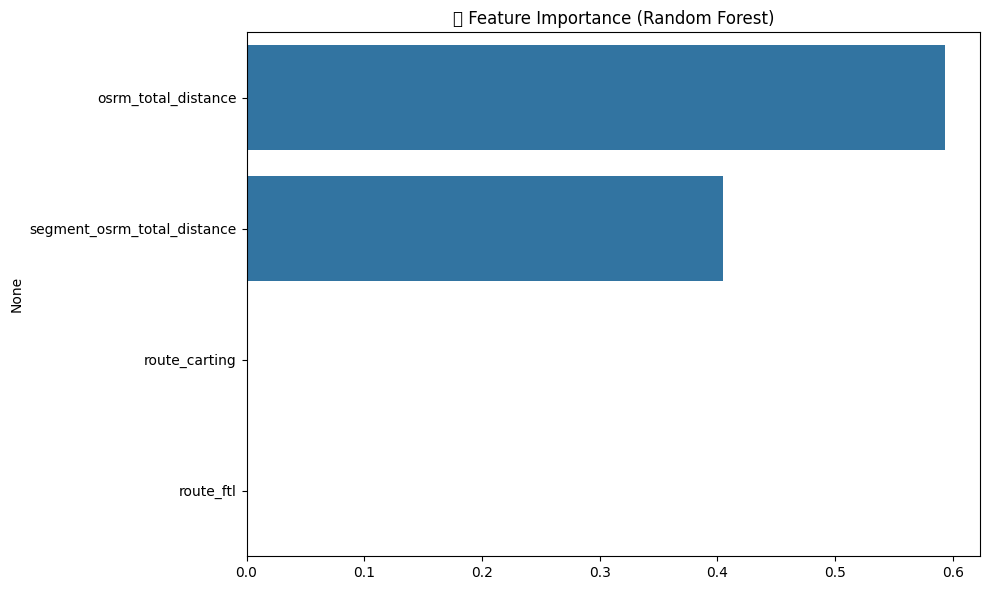

In [ ]:
#Feature Importance

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

#Business Insights

1. Fast Fulfillment: 75% of Deliveries Take <6 Hours:

  *   Insight: Most deliveries are completed within the same day.

  *   Recommendation: Emphasize this as a competitive advantage in marketing and SLA negotiations. Explore reducing the 6-hour window to improve even further.


2. Distance vs. Time: OSRM > Actual Correlation:

    *  Insight: High correlation between OSRM distance & OSRM time, but low correlation between actual distance & actual time.

    * Recommendation: Investigate non-distance-related delays — such as stopovers, manual processes, or regional road conditions. Implement route audit reports.


3. Geographic Hotspots: Maharashtra, Karnataka, Haryana

      * Insight: These states account for ~40% of deliveries.
      
      * Recommendation: Focus infrastructure, hub optimization, and resource allocation (drivers, trucks) in these regions. Tailor SLA guarantees accordingly.


4. FTL (Full Truck Load) Dominates (70%):

  * Insight: Full Truck Load is the most common mode.

  * Recommendation: Since FTL also yields better performance ,expand its use where possible. Incentivize clients to opt for FTL.


5. FTL vs Carting: FTL is Faster

     * Insight: Avg. speed for FTL is ~10 km/h more than Carting.

     * Recommendation: Reassess the viability of Carting. Reserve it for low-priority or short-distance tasks. Provide performance-based pricing to push FTL.



6. Documented Time is Much Higher than Actual Time:

    * Insight: Big gap between reported trip time and true delivery time.

    * Recommendation: Audit trip documentation procedures. Shorten buffer windows or update SLA windows to reflect operational reality.







